In [1]:
# The following lines enable automatic reloading of modules in an IPython/Jupyter environment.
# They work exactly like the commented lines below, but avoid errors when not running in such an environment.
# %load_ext autoreload
# %autoreload 2

try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except (NameError, AttributeError):
    pass


In [2]:
answer = {}


In [3]:
import random
from pprint import pprint

import json_tricks
import matplotlib
import numpy as np
import torch
import torch.nn.functional as F

matplotlib.use('Agg')
import matplotlib.pyplot as plt

import sys
root_path = '../../../..'
sys.path.append(root_path)

import dotenv
dotenv.load_dotenv(dotenv.find_dotenv(root_path + '/.env'))

import src
from src import utils


# Simple GAN With Gradient Reversal

A generative adversarial network has two trainable parts:

- a generator that maps a random noise vector to an image-shaped vector;
- a discriminator that receives both generated and real images and predicts which inputs are real.

In this exercise we use one shared backpropagation pass instead of alternating separate generator and discriminator steps. The generated samples pass through a `GradientReversalLayer` before the discriminator sees them:

`noise -> generator -> gradient reversal -> discriminator -> classifier`

The gradient-reversal layer does nothing to the forward value. During backpropagation it multiplies the gradient by `-strength`, so the discriminator learns the normal real/fake classification task while the generator receives the opposite signal and learns to make fake images look more real.

The networks use `LeakyReLU(negative_slope=0.5)` by default. The slope is deliberately large: if the discriminator becomes much better than the generator, ordinary ReLU-style activations and saturated classifier logits can leave the generator with tiny useful gradients. A strong leaky branch keeps negative activations informative and helps gradients keep flowing through the discriminator path back toward the generator.


# Task 0: Prepare the Environment

## Goal

Set all random seeds with `src.utils.seed.seed_all(0)`. Reproducibility matters here because generated examples and training curves are easier to compare when initialization and dataloader shuffling are deterministic.

## Implementation Details

Write the seed call in the cell below. The expected student code should be placed after `## YOUR CODE HERE`.


In [4]:
## YOUR CODE HERE
import src.utils.seed
src.utils.seed.seed_all(0)

seed_check = {
    'python.random': [random.random() for _ in range(4)],
    'numpy.random.rand': np.random.rand(2, 3),
    'torch.rand': torch.rand(2, 3),
    'torch.backends.cudnn.deterministic': torch.backends.cudnn.deterministic,
}
answer['seed_check'] = seed_check
pprint(seed_check)


{'numpy.random.rand': array([[0.5488135 , 0.71518937, 0.60276338],
       [0.54488318, 0.4236548 , 0.64589411]]),
 'python.random': [0.8444218515250481,
                   0.7579544029403025,
                   0.420571580830845,
                   0.25891675029296335],
 'torch.backends.cudnn.deterministic': True,
 'torch.rand': tensor([[0.4963, 0.7682, 0.0885],
        [0.1320, 0.3074, 0.6341]])}


# Task 1: Reuse MNIST and Add Noise

Reuse `MNISTSimpleDataset` from the earlier tasks and wrap it in `NoiseMNISTDataset`. The wrapper should return the real MNIST sample together with a deterministic random vector that will become the generator input.

Implement `NoiseMNISTDataset.__getitem__` so that every item is a dictionary with:

- `noise`: a vector of length `self.noise_dim`, sampled from a standard normal distribution;
- `image`: the real MNIST image from the base dataset;
- `label`: the original MNIST digit label, used only for visualization.

The noise must be deterministic for each index. Create a local `torch.Generator`, seed it with `self.base_seed + int(index)`, and pass it to `torch.randn`. Use the same dtype as `sample['image']`.

After the class is implemented, set:

- `noise_dim = 256`;
- `MNIST_train = src.datasets.mnist_simple.MNISTSimpleDataset(train=True)`;
- `MNIST_valid = src.datasets.mnist_simple.MNISTSimpleDataset(train=False)`;
- `train_dataset = NoiseMNISTDataset(MNIST_train, noise_dim=noise_dim, base_seed=10_000)`;
- `valid_dataset = NoiseMNISTDataset(MNIST_valid, noise_dim=noise_dim, base_seed=20_000)`.


In [5]:
class NoiseMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, noise_dim, base_seed=0):
        self.base_dataset = base_dataset
        self.noise_dim = int(noise_dim)
        self.base_seed = int(base_seed)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        ## YOUR CODE HERE
        sample = self.base_dataset[index]
        gen = torch.Generator()
        gen.manual_seed(self.base_seed + int(index))
        noise = torch.randn(self.noise_dim, generator=gen, dtype=sample['image'].dtype)
        return {
            #'noise': torch.zeros(self.noise_dim, dtype=sample['image'].dtype),
            'noise': noise,
            'image': sample['image'],
            'label': sample['label'],
        }


noise_dim = 256
MNIST_train = None
MNIST_valid = None
train_dataset = None
valid_dataset = None

## YOUR CODE HERE
MNIST_train = src.datasets.mnist_simple.MNISTSimpleDataset(train=True)
MNIST_valid = src.datasets.mnist_simple.MNISTSimpleDataset(train=False)
train_dataset = NoiseMNISTDataset(MNIST_train, noise_dim=noise_dim, base_seed=10_000)
valid_dataset = NoiseMNISTDataset(MNIST_valid, noise_dim=noise_dim, base_seed=20_000)

train_sample = train_dataset[0]
valid_sample = valid_dataset[0]

print('noise dtype:', train_sample['noise'].dtype)
print('noise shape:', train_sample['noise'].shape)
print('image dtype:', train_sample['image'].dtype)
print('image shape:', train_sample['image'].shape)

fig, axes = plt.subplots(1, 2, figsize=(5, 2.4), constrained_layout=True)
axes[0].plot(train_sample['noise'])
axes[0].set_title('noise')
axes[1].imshow(train_sample['image'], cmap='gray')
axes[1].set_title(f"real digit {int(train_sample['label'])}")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

answer['noise_shape'] = list(train_sample['noise'].shape)
answer['noise_dtype'] = str(train_sample['noise'].dtype)
answer['image_shape'] = list(train_sample['image'].shape)
answer['image_dtype'] = str(train_sample['image'].dtype)
answer['label_dtype'] = str(train_sample['label'].dtype)
answer['noise_mean'] = float(train_sample['noise'].mean())
answer['image_mean'] = float(train_sample['image'].mean())


noise dtype: torch.float32
noise shape: torch.Size([256])
image dtype: torch.float32
image shape: torch.Size([28, 28])


/tmp/ipykernel_2732052/1320555354.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# Task 2: Build the Gradient-Reversal GAN

Edit [src/models/feedforward/adversarial.py](../../../../src/models/feedforward/adversarial.py) and implement the `GAN` class. The implementation belongs in `adversarial.py`, next to `GradientReversalLayer`.

Implement the two placeholder regions: `__init__` and `forward`.

In `__init__`, create these modules:

- `self.generator_discriminator_bridge = GradientReversalLayer(gradient_reversal_strength)`;
- `self.gradient_reversal` as an alias of the same layer;
- `self.generator`: fully connected layers `noise_dim -> 256 -> 784`, using a fresh copy of the activation after each hidden linear layer, then `torch.nn.Tanh()` at the end so generated pixels live near the MNIST `[-1, 1]` scale;
- `self.discriminator`: fully connected layers `784 -> 256 -> noise_dim`, again using fresh activation modules between linear layers;
- `self.classifier`: a final `Linear(noise_dim, 1)` that produces one raw real/fake logit per image.

The default activation is `LeakyReLU(negative_slope=0.5)`. Keep that high negative slope unless you are deliberately experimenting: it helps fight low-gradient behavior when the discriminator gets too confident too early.

In `forward`, implement this data path:

`noise -> generator -> gradient reversal -> concatenate with real images -> discriminator -> classifier`

The model reads `batch['data']['noise']` and either `batch['data']['real']` or `batch['data']['image']`. Flatten real images before concatenation. The classifier outputs raw logits: larger logits mean "more real", smaller logits mean "more fake".

The required outputs are:

- `batch['signals']['generated']`;
- `batch['signals']['discriminator_logits']` for the concatenated fake plus real batch;
- `batch['signals']['fake_logits']`;
- `batch['signals']['real_logits']` when real images are present;
- matching convenience aliases `discriminator_scores`, `fake_scores`, and `real_scores`;
- `batch['postprocessed']` entries with logits/scores and sigmoid probabilities for quick inspection.

A separate `discriminate` helper is not part of the required student-facing API. It may be kept as a small internal helper if the surrounding file already has it, but the required behavior is the `forward` protocol above.


In [6]:
gan_model = src.models.feedforward.adversarial.GAN(
    [noise_dim, 512, 28 * 28],
    gradient_reversal_strength=1.0
)
utils.deterministic_init(gan_model)

check_batch = {
    'data': {
        'noise': torch.randn(10, noise_dim),
        'image': torch.randn(10, 28, 28),
    }
}
with torch.no_grad():
    gan_model(check_batch)

print('generated:', check_batch['signals']['generated'].shape)
print('discriminator logits:', check_batch['signals']['discriminator_logits'].shape)
print('fake logits:', check_batch['signals']['fake_logits'].shape)
print('real logits:', check_batch['signals']['real_logits'].shape)

answer['check_batch'] = check_batch
answer['generated_shape'] = list(check_batch['signals']['generated'].shape)
answer['discriminator_logits_shape'] = list(check_batch['signals']['discriminator_logits'].shape)
answer['fake_logits_shape'] = list(check_batch['signals']['fake_logits'].shape)
answer['real_logits_shape'] = list(check_batch['signals']['real_logits'].shape)
answer['bridge_class'] = gan_model.generator_discriminator_bridge.__class__.__name__


generated: torch.Size([10, 784])
discriminator logits: torch.Size([20])
fake logits: torch.Size([10])
real logits: torch.Size([10])


## Model Graph

A model graph is a compact way to check the full adversarial signal path: noise becomes a generated image, generated and real images meet in the discriminator, and the classifier emits real/fake logits.

The gradient-reversal layer appears on the generated branch because it is the piece that turns one binary classification loss into opposite learning signals for the two networks.


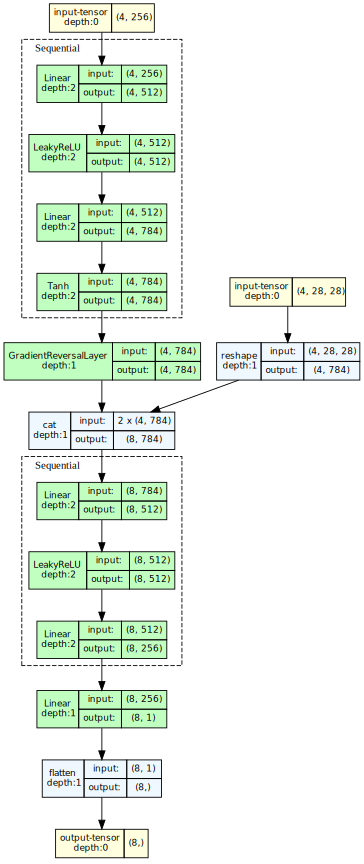

In [7]:
from torchview import draw_graph


class GANGraphAdapter(torch.nn.Module):
    def __init__(self, gan):
        super().__init__()
        self.gan = gan

    def forward(self, noise, real_image):
        generated = self.gan.generator(noise)
        reversed_generated = self.gan.generator_discriminator_bridge(generated)
        real_image = real_image.reshape(real_image.shape[0], -1)
        discriminator_input = torch.cat([reversed_generated, real_image], dim=0)
        features = self.gan.discriminator(discriminator_input)
        return self.gan.classifier(features).flatten()


gan_graph = draw_graph(
    GANGraphAdapter(gan_model),
    input_data=(torch.randn(4, noise_dim), torch.randn(4, 28, 28)),
    expand_nested=True,
    graph_name='GradientReversalGAN',
)
gan_graph.visual_graph



# Task 3: Create the Standard GAN Classification Loss, Optimizer, and Metrics

Create one binary classification loss over generated and real logits.

Implement `gan_classification_loss(batch)` with `torch.nn.functional.binary_cross_entropy_with_logits`:

- `fake_logits` should be compared with zero targets, because the discriminator should classify generated samples as fake;
- `real_logits` should be compared with one targets, because the discriminator should classify real MNIST samples as real;
- return `fake_loss + real_loss`.

Because generated samples pass through the gradient-reversal layer, this same loss trains the two sides in opposite directions. The discriminator is rewarded for recognizing fake samples, while the generator receives the reversed fake-sample gradient and is rewarded for making fake samples look real.

Implement `discriminator_accuracy(batch)` by thresholding logits at `0`:

- fake logits are correct when they are `< 0`;
- real logits are correct when they are `>= 0`;
- return `(correct_count, total_count)`.

Set:

- `losses = {'classification': gan_classification_loss}`;
- `metrics = {'discriminator_accuracy': discriminator_accuracy}`;
- one `AdamW` optimizer with two parameter groups: generator parameters at learning rate `2.0e-4`, discriminator plus classifier parameters at learning rate `1.0e-4`.

Do not add a learning-rate scheduler for this GAN task. GAN training is already a balance between two networks; changing both learning rates automatically from one validation loss can make that balance harder to reason about in this simplified setup.

The generator learning rate is intentionally a little higher than the discriminator learning rate. Together with the high-slope `LeakyReLU`, this helps the generator keep receiving useful updates when the discriminator learns the easy real/fake separation too quickly.


In [8]:
def gan_classification_loss(batch):
    fake_logits = batch['signals']['fake_logits']
    real_logits = batch['signals']['real_logits']
    fake_targets = torch.zeros_like(fake_logits)
    real_targets = torch.ones_like(real_logits)
    fake_loss = F.binary_cross_entropy_with_logits(fake_logits, fake_targets)
    real_loss = F.binary_cross_entropy_with_logits(real_logits, real_targets)
    return fake_loss + real_loss


def discriminator_accuracy(batch):
    fake_logits = batch['signals']['fake_logits']
    real_logits = batch['signals']['real_logits']
    fake_correct = (fake_logits < 0).sum()
    real_correct = (real_logits >= 0).sum()
    correct = fake_correct + real_correct
    total = torch.tensor(fake_logits.numel() + real_logits.numel(), device=correct.device)
    return correct, total

losses = {'classification': gan_classification_loss}
metrics = {'discriminator_accuracy': discriminator_accuracy}
#optimizer = torch.optim.AdamW(gan_model.parameters(), lr=1.0e-3)

## YOUR CODE HERE
optimizer = torch.optim.AdamW([
    {'params': gan_model.generator.parameters(), 'lr': 2.0e-4},
    {'params': list(gan_model.discriminator.parameters()) + list(gan_model.classifier.parameters()), 'lr': 1.0e-4},
])

loss_check_batch = {
    'data': {
        'noise': torch.randn(8, noise_dim),
        'image': torch.randn(8, 28, 28),
    }
}
gan_model(loss_check_batch)
test_loss_val = {name: fn(loss_check_batch) for name, fn in losses.items()}
test_metrics_val = {name: fn(loss_check_batch) for name, fn in metrics.items()}

answer['loss_names'] = list(losses.keys())
answer['metric_names'] = list(metrics.keys())
answer['optimizer_class'] = optimizer.__class__.__name__
answer['optimizer_defaults'] = dict(optimizer.defaults)
answer['optimizer_group_lrs'] = [group['lr'] for group in optimizer.param_groups]
answer['test_loss_val'] = test_loss_val
answer['test_metrics_val'] = test_metrics_val



# Task 4: Create DataLoaders

Create dataloaders for the noise-plus-MNIST datasets.

Use `torch.utils.data.DataLoader` with:

- `batch_size = 64`;
- `shuffle=True` and `drop_last=True` for `train_dl`;
- `shuffle=False` and `drop_last=True` for `valid_dl`.

The training loop expects each dataloader batch to contain `noise`, `image`, and `label`. The model will wrap each dataloader batch into `{'data': batch}` internally.


In [9]:
batch_size = None
train_dl = None
valid_dl = None

## YOUR CODE HERE
batch_size = 64
train_dl = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
valid_dl = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

train_batch = next(iter(train_dl))
valid_batch = next(iter(valid_dl))

pprint(train_batch)

answer['train_batch'] = str(train_batch)
answer['valid_batch'] = str(valid_batch)


{'image': tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        ...,

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1.,

# Task 5: Train With the Shared Training Loop

Reuse `src.train_loop.train_model`. Do not write a custom GAN training loop, and do not pass a scheduler for this task.

For each batch, the `GAN.forward` method builds the combined fake-plus-real discriminator batch internally. The shared training loop computes the single classification loss, calls one backward pass, and lets the gradient-reversal layer send the opposite fake-sample gradient into the generator.

Store the returned histories for:

- training and validation classification loss;
- training and validation discriminator accuracy.


In [10]:
n_epochs = 3

training_logger = src.utils.mlflow.prepare_mlflow_logger('gradient_reversal_gan')

training_history = src.train_loop.train_model(
    gan_model,
    n_epochs,
    train_dl,
    valid_dl,
    losses,
    optimizer,
    metrics=metrics,
    mlflow_logger=training_logger,
    run_name='gradient_reversal_gan',
)

train_gan_loss_history = training_history['train_loss']['classification']
valid_gan_loss_history = training_history['valid_loss']['classification']
train_discriminator_accuracy_history = training_history['train_metrics']['discriminator_accuracy']
valid_discriminator_accuracy_history = training_history['valid_metrics']['discriminator_accuracy']

training_logger.end()

answer['train_gan_loss_history'] = train_gan_loss_history
answer['valid_gan_loss_history'] = valid_gan_loss_history
answer['train_discriminator_accuracy_history'] = train_discriminator_accuracy_history
answer['valid_discriminator_accuracy_history'] = valid_discriminator_accuracy_history


MLflow is not installed. Install it with `pip install mlflow` to enable experiment logging.

epochs:   0%|          | 0/3 [00:00<?, ?it/s]

batches:   0%|          | 0/937 [00:00<?, ?it/s]

/home/dest85v/Projects/neural-networks-fundamentals/.laborantum/src/utils/mlflow.py:291: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/home/dest85v/Projects/neural-networks-fundamentals/.laborantum/src/utils/mlflow.py:307: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# Generated Images

After the short checker-friendly run, generated digits may still look rough. The goal here is not a polished generative model; the goal is to verify that the full adversarial path runs and produces image-shaped samples from noise.

The generator ends with `Tanh`, so plot generated images with the same `[-1, 1]` value range used for MNIST in the earlier tasks.


In [11]:
with torch.no_grad():
    gan_model.eval()
    visualization_noise = valid_batch['noise'][:16]
    generated_images = gan_model.generator(visualization_noise).reshape(-1, 28, 28)
    


fig, axes = plt.subplots(2, 8, figsize=(10, 2.8), constrained_layout=True)
for index, ax in enumerate(axes.flat):
    ax.imshow(generated_images[index], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')
fig.suptitle('generated MNIST-like samples')
plt.show()

answer['generated_visualization_shape'] = list(generated_images.shape)
answer['generated_visualization_mean'] = float(generated_images.mean())

json_tricks.dump(utils.torch_to_numpy(answer), '.answer.json')


/tmp/ipykernel_2732052/2941794126.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


'{"seed_check": {"python.random": [0.8444218515250481, 0.7579544029403025, 0.420571580830845, 0.25891675029296335], "numpy.random.rand": {"__ndarray__": [[0.5488135039273248, 0.7151893663724195, 0.6027633760716439], [0.5448831829968969, 0.4236547993389047, 0.6458941130666561]], "dtype": "float64", "shape": [2, 3], "Corder": true}, "torch.rand": {"__ndarray__": [[0.49625658988952637, 0.7682217955589294, 0.08847743272781372], [0.13203048706054688, 0.30742281675338745, 0.6340786814689636]], "dtype": "float32", "shape": [2, 3], "Corder": true}, "torch.backends.cudnn.deterministic": true}, "noise_shape": [256], "noise_dtype": "torch.float32", "image_shape": [28, 28], "image_dtype": "torch.float32", "label_dtype": "torch.int64", "noise_mean": -0.03508780151605606, "image_mean": -0.7246397137641907, "check_batch": {"data": {"noise": {"__ndarray__": [[0.27989619970321655, 0.5762641429901123, 0.35762307047843933, 0.6955746412277222, -2.521540880203247, 0.8111782670021057, 1.279000163078308, -0.

In [12]:
print(generated_images.min(), generated_images.max())


tensor(-1.) tensor(1.)


# Task 6: Experiment Time

The checker uses the short training run above. After that works, try longer experiments.

You can run experiments uncommenting the code below.

Although this code gives you some visible results, they are definitily
not good. Start with reducing learning rate to `2.0e-5` and `1.0e-5` for 
the generator and the discriminator respectively. 

Useful experiments:

- change the noise dimensionality;
- make the generator or discriminator wider;
- inspect how generated images change during training;
- try different `gradient_reversal_strength` values;
- compare smaller and larger `LeakyReLU` negative slopes. A very small slope can make the generator's gradients fade when the discriminator is already confident, while a larger slope keeps more signal moving through negative activations;
- manually tune the generator and discriminator learning rates. Avoid automatic schedulers at first, because a GAN's two-sided optimization can become harder to interpret when both learning rates change implicitly.


## Why GANs Are Hard To Train

The central difficulty in many GANs is not only that two networks are trained at once. A deeper problem is that the generator can receive very small or poorly shaped gradients when the discriminator works too well. If the discriminator confidently separates real and generated samples, its own classification signal is very informative, but the generator may get a weak training signal about how to move its samples toward the real data distribution.

Many GAN variants try to repair this gradient problem. Wasserstein GANs replace the classifier view with a smoother critic objective. MSE or least-squares GANs change the classification loss so gradients decay less abruptly. Other methods adjust architectures, regularization, update schedules, noise injection, normalization, or the way real and fake targets are represented.

These fixes help, but they do not remove the basic tension: the discriminator often gets a more direct and more informative gradient than the generator. Training a GAN is largely about keeping that game balanced enough for both networks to keep learning.


In [ ]:
# # # Optional long-run area. Do not include this in checker-facing answers.

# long_gan_model = src.models.feedforward.adversarial.GAN(
#     [256, 512, 28 * 28],
#     gradient_reversal_strength=1.0,
# )
# long_optimizer = torch.optim.AdamW(
#     [
#         {'params': long_gan_model.generator.parameters(), 'lr': 2.0e-5},
#         {
#             'params': list(long_gan_model.discriminator.parameters()) + list(long_gan_model.classifier.parameters()),
#             'lr': 1.0e-5,
#         },
#     ]
# )
# long_logger = src.utils.mlflow.prepare_mlflow_logger('gradient_reversal_gan_long_run')
# long_history = src.train_loop.train_model(
#     long_gan_model,
#     100,
#     train_dl,
#     valid_dl,
#     losses,
#     long_optimizer,
#     metrics=metrics,
#     mlflow_logger=long_logger,
#     run_name='gradient_reversal_gan_long_run',
# )
# long_logger.end()



In [ ]:
# with torch.no_grad():
#     gan_model.eval()
#     visualization_noise = valid_batch['noise'][:16]
#     generated_images = long_gan_model.generator(visualization_noise).reshape(-1, 28, 28)

# fig, axes = plt.subplots(2, 8, figsize=(10, 2.8), constrained_layout=True)
# for index, ax in enumerate(axes.flat):
#     ax.imshow(generated_images[index], cmap='gray', vmin=-1, vmax=1)
#     ax.axis('off')
# fig.suptitle('generated MNIST-like samples')
# plt.show()

# answer['generated_visualization_shape'] = list(generated_images.shape)
# answer['generated_visualization_mean'] = float(generated_images.mean())

# json_tricks.dump(utils.torch_to_numpy(answer), '.answer.json')
